In [32]:
import numpy as np
embeddings_array=np.load("/kaggle/input/datasets/nileshthota/query-time-prediction-data/bert_embeds.npy")
X_bert=np.array(embeddings_array)
embeddings_array=np.load("/kaggle/input/datasets/nileshthota/query-time-prediction-data/lstm_embeds.npy")
X_lstm=np.array(embeddings_array)
embeddings_array=np.load("/kaggle/input/datasets/nileshthota/query-time-prediction-data/doc2vec_embeddings.npy")
X_doc2vec=np.array(embeddings_array)

In [3]:
# 1. Clone the repository structure without downloading all files (blobs)
!git clone --depth 1 --filter=blob:none --sparse https://github.com/SQL-Storm/SQLStorm.git

# 2. Navigate into the repository
%cd SQLStorm

# 3. Configure Git to only download the specific subdirectory you need
!git sparse-checkout set v1.0/stackoverflow/queries

Cloning into 'SQLStorm'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 54 (delta 3), reused 46 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 12.63 MiB | 28.29 MiB/s, done.
Resolving deltas: 100% (3/3), done.
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 5.31 KiB | 5.31 MiB/s, done.
/kaggle/working/SQLStorm
remote: Enumerating objects: 17314, done.
remote: Counting objects: 100% (17314/17314), done.
remote: Compressing objects: 100% (16077/16077), done.
remote: Total 17314 (delta 1235), reused 17308 (delta 1233), pack-reused 0 (from 0)
Receiving objects: 100% (17314/17314), 7.75 MiB | 17.28 MiB/s, done.
Resolving deltas: 100% (1235/1235), done.
Updating files: 100% (18258/18258), don

In [4]:
path="/kaggle/working/SQLStorm/v1.0/stackoverflow/queries"
import pandas as pd
import os


def load_sql_dir(directory):
    """
    Load every .sql file in `directory` into a pandas DataFrame.

    Parameters
    ----------
    directory : str
        Path to the folder containing .sql files.

    Returns
    -------
    pd.DataFrame
        Columns: ['file_name', 'sql_text']
    """
    records = []

    for file_name in sorted(os.listdir(directory)):
        if file_name.lower().endswith(".sql"):
            file_path = os.path.join(directory, file_name)
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    sql_text = f.read()
                records.append({"file_name": file_name, "sql_text": sql_text})
            except (FileNotFoundError, PermissionError, UnicodeDecodeError) as e:
                print(f"[SKIP] {file_path} → {e}")

    df = pd.DataFrame(records, columns=["file_name", "sql_text"])
    print(f"Loaded {len(df)} .sql files from {directory}")
    return df
df_stackoverflow=load_sql_dir(path)

Loaded 18251 .sql files from /kaggle/working/SQLStorm/v1.0/stackoverflow/queries


In [5]:
import pandas as pd
import json

records = []
with open('/kaggle/input/datasets/nileshthota/query-runtimes/complete_ground_truth.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            obj = json.loads(line)
            records.append({
                'query_id': obj['query_id'],
                'execution_time_ms': obj['execution_time_ms']
            })

df = pd.DataFrame(records)
print(df.shape)
print(df.head())

(13930, 2)
    query_id  execution_time_ms
0   3359.sql           5231.190
1  12113.sql           6756.338
2  15140.sql           2499.640
3  13256.sql           8403.016
4  32707.sql           3085.003


In [34]:
df_stackoverflow["bert_embeds"] = pd.Series(list(X_bert), index=df_stackoverflow.index)
df_stackoverflow["lstm_embeds"] = pd.Series(list(X_lstm), index=df_stackoverflow.index)
df_stackoverflow["doc2vec_embeds"] = pd.Series(list(X_doc2vec), index=df_stackoverflow.index)


In [35]:
df_Xy = df.merge(
    df_stackoverflow,
    left_on="query_id",
    right_on="file_name",
    how="inner"
)
df_Xy.drop(columns="file_name", inplace=True)
print(df_Xy.shape)
print(df_Xy.head())

(13930, 6)
    query_id  execution_time_ms  \
0   3359.sql           5231.190   
1  12113.sql           6756.338   
2  15140.sql           2499.640   
3  13256.sql           8403.016   
4  32707.sql           3085.003   

                                            sql_text  \
0  \nWITH RankedPosts AS (\n    SELECT \n        ...   
1  \nSELECT \n    p.Id AS PostId,\n    p.Title,\n...   
2  \nSELECT \n    p.Id AS PostId,\n    p.Title,\n...   
3  \nWITH UserStats AS (\n    SELECT \n        U....   
4  WITH RankedPosts AS (\n    SELECT \n        p....   

                                         bert_embeds  \
0  [-0.4272088, 0.095720306, -0.16653752, -0.6466...   
1  [-0.39112598, -0.39090908, -0.55298424, -0.102...   
2  [-0.45172128, -0.31436297, -0.43628693, -0.190...   
3  [-0.9103037, -0.069108754, -0.3374475, -0.2909...   
4  [-0.23789002, 0.030624878, 0.0028580248, -0.47...   

                                         lstm_embeds  \
0  [-0.5112846, -0.035142355, -0.20343366, 0.175

In [36]:
# ---- Imports / config ----
import os, time, warnings
import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge,SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

PLOTS_DIR = "/kaggle/working/time_prediction_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

np.random.seed(42)

In [53]:
df_Xy = df_Xy.dropna(subset=["bert_embeds", "lstm_embeds", "doc2vec_embeds", "execution_time_ms"]).reset_index(drop=True)

X_bert = np.vstack(df_Xy["bert_embeds"].values).astype(np.float32)
X_lstm = np.vstack(df_Xy["lstm_embeds"].values).astype(np.float32)
X_doc2vec = np.vstack(df_Xy["doc2vec_embeds"].values).astype(np.float32)

X_concat = np.hstack([X_bert, X_lstm]).astype(np.float32)
y = df_Xy["execution_time_ms"].values.astype(np.float32)

print("Shapes:")
print("  X_bert    :", X_bert.shape)
print("  X_lstm    :", X_lstm.shape)
print("  X_doc2vec :", X_doc2vec.shape)
print("  X_concat  :", X_concat.shape)
print("  y         :", y.shape)

Shapes:
  X_bert    : (13930, 768)
  X_lstm    : (13930, 256)
  X_doc2vec : (13930, 64)
  X_concat  : (13930, 1024)
  y         : (13930,)


In [54]:
idx_all = np.arange(len(y))

idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f"Split sizes -> Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")

Split sizes -> Train: 9751, Val: 2089, Test: 2090


In [55]:
# ---- Metrics helpers ----
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_metrics(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE%": mape(y_true, y_pred)
    }

In [56]:
# ---- Model configs ----
# Note: For high-dim embeddings, Ridge usually performs very well.
# Tree models may be slower and sometimes worse in high dimension.

models_config = [
    # Very strong + very fast on embeddings
    ("Ridge (BERT)",      "bert",   Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])),
    ("Ridge (LSTM)",      "lstm",   Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])),
    ("Ridge (DOC2VEC)", "doc2vec", Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])),


]


In [57]:
# ---- Training loop ----
features = {"bert": X_bert, "lstm": X_lstm, "doc2vec": X_doc2vec}

results = []
trained = {}
predictions = {}  # store val/test preds for plotting

for name, feat_key, model in models_config:
    X = features[feat_key]
    X_tr, y_tr = X[idx_train], y[idx_train]
    X_va, y_va = X[idx_val], y[idx_val]
    X_te, y_te = X[idx_test], y[idx_test]

    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    pred_tr = model.predict(X_tr)
    pred_va = model.predict(X_va)
    pred_te = model.predict(X_te)

    tr_m = eval_metrics(y_tr, pred_tr)
    va_m = eval_metrics(y_va, pred_va)
    te_m = eval_metrics(y_te, pred_te)

    results.append({
        "Model": name,
        "Feat": feat_key,
        "Train R2": tr_m["R2"],
        "Val R2": abs(va_m["R2"]),
        "Test R2": abs(te_m["R2"]),
        "Val MAE": va_m["MAE"],
        "Val RMSE": va_m["RMSE"],
        "Val MAPE%": va_m["MAPE%"],
        "Test MAE": te_m["MAE"],
        "Test RMSE": te_m["RMSE"],
        "Train Time (s)": round(train_time, 2),
    })

    trained[name] = (model, feat_key)
    predictions[name] = {
        "val": (y_va, np.clip(pred_va, 0, None)),
        "test": (y_te, np.clip(pred_te, 0, None))
    }

    print(f"{name:<22} | Val R2={abs(va_m['R2']):.4f}  MAE={va_m['MAE']:.1f}ms  RMSE={va_m['RMSE']:.1f}ms  time={train_time:.2f}s")

results_df = pd.DataFrame(results).sort_values("Val R2", ascending=False)
results_df.to_csv("/kaggle/working/model_results.csv", index=False)

print("\nTop results:")
print(results_df[["Model","Val R2","Val MAE","Val RMSE","Test R2","Train Time (s)"]].head(10).to_string(index=False))
print("\nSaved table to /kaggle/working/model_results.csv")

Ridge (BERT)           | Val R2=0.5642  MAE=1524.9ms  RMSE=2077.0ms  time=0.30s
Ridge (LSTM)           | Val R2=0.6142  MAE=1441.2ms  RMSE=1954.3ms  time=0.06s
Ridge (DOC2VEC)        | Val R2=0.6068  MAE=1531.4ms  RMSE=1972.9ms  time=0.02s

Top results:
          Model   Val R2     Val MAE    Val RMSE  Test R2  Train Time (s)
   Ridge (LSTM) 0.614173 1441.151978 1954.313818 0.590574            0.06
Ridge (DOC2VEC) 0.606797 1531.397095 1972.905725 0.577080            0.02
   Ridge (BERT) 0.564217 1524.891235 2076.982065 0.568740            0.30

Saved table to /kaggle/working/model_results.csv


In [58]:
results_df

,Model,Feat,Train R2,Val R2,Test R2,Val MAE,Val RMSE,Val MAPE%,Test MAE,Test RMSE,Train Time (s)
1,Ridge (LSTM),lstm,0.625970,0.614173,0.590574,1441.151978,1954.313818,4204.943848,1488.606445,2045.244301,0.06
2,Ridge (DOC2VEC),doc2vec,0.592627,0.606797,0.577080,1531.397095,1972.905725,3895.669922,1615.456299,2078.672894,0.02
0,Ridge (BERT),bert,0.645391,0.564217,0.568740,1524.891235,2076.982065,3876.985107,1519.354736,2099.070389,0.30


In [59]:
def plot_predicted_vs_actual(predictions, results_df, split="test", top_k=4, out_path=None):
    top_models = results_df["Model"].head(top_k).tolist()
    fig, axes = plt.subplots(1, len(top_models), figsize=(6*len(top_models), 5))
    if len(top_models) == 1:
        axes = [axes]

    for ax, mname in zip(axes, top_models):
        y_true, y_pred = predictions[mname][split]
        ax.scatter(y_true, y_pred, alpha=0.35, s=12, c="teal", edgecolors="none")
        lim = max(y_true.max(), y_pred.max()) * 1.05
        ax.plot([0, lim], [0, lim], "r--", lw=1)
        ax.set_title(f"{mname}\nR2={r2_score(y_true,y_pred):.4f}  MAE={mean_absolute_error(y_true,y_pred):.0f}ms", fontsize=10)
        ax.set_xlabel("Actual (ms)")
        ax.set_ylabel("Predicted (ms)")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

def plot_residuals(predictions, best_model, split="test", out_path=None):
    y_true, y_pred = predictions[best_model][split]
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_pred, residuals, alpha=0.35, s=12, c="coral")
    axes[0].axhline(0, color="black", lw=1)
    axes[0].set_xlabel("Predicted (ms)")
    axes[0].set_ylabel("Residual (ms)")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(f"Residuals: {best_model}")

    axes[1].hist(residuals, bins=40, color="coral", edgecolor="k", alpha=0.7)
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_xlabel("Residual (ms)")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title("Residual distribution")

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

def plot_model_comparison(results_df, out_path=None):
    dfp = results_df.copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric, title in zip(
        axes,
        ["Val R2", "Val MAE", "Val RMSE"],
        ["Val R2 ", "Val MAE ", "Val RMSE "]
    ):
        ax.barh(dfp["Model"], dfp[metric], color="#3498db", edgecolor="k", linewidth=0.5)
        ax.set_title(title)
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [60]:
%matplotlib inline
# ---- Generate plots ----
best_model = results_df.iloc[0]["Model"]
print("Best model:", best_model)

plot_model_comparison(results_df, out_path=f"{PLOTS_DIR}/0_model_comparison.png")

plot_predicted_vs_actual(
    predictions, results_df, split="val", top_k=4,
    out_path=f"{PLOTS_DIR}/1_pred_vs_actual_VAL.png"
)

plot_predicted_vs_actual(
    predictions, results_df, split="test", top_k=4,
    out_path=f"{PLOTS_DIR}/2_pred_vs_actual_TEST.png"
)

plot_residuals(
    predictions, best_model, split="test",
    out_path=f"{PLOTS_DIR}/3_residuals_TEST_best.png"
)

print("Saved plots to:", PLOTS_DIR)

Best model: Ridge (LSTM)
Saved plots to: /kaggle/working/time_prediction_plots


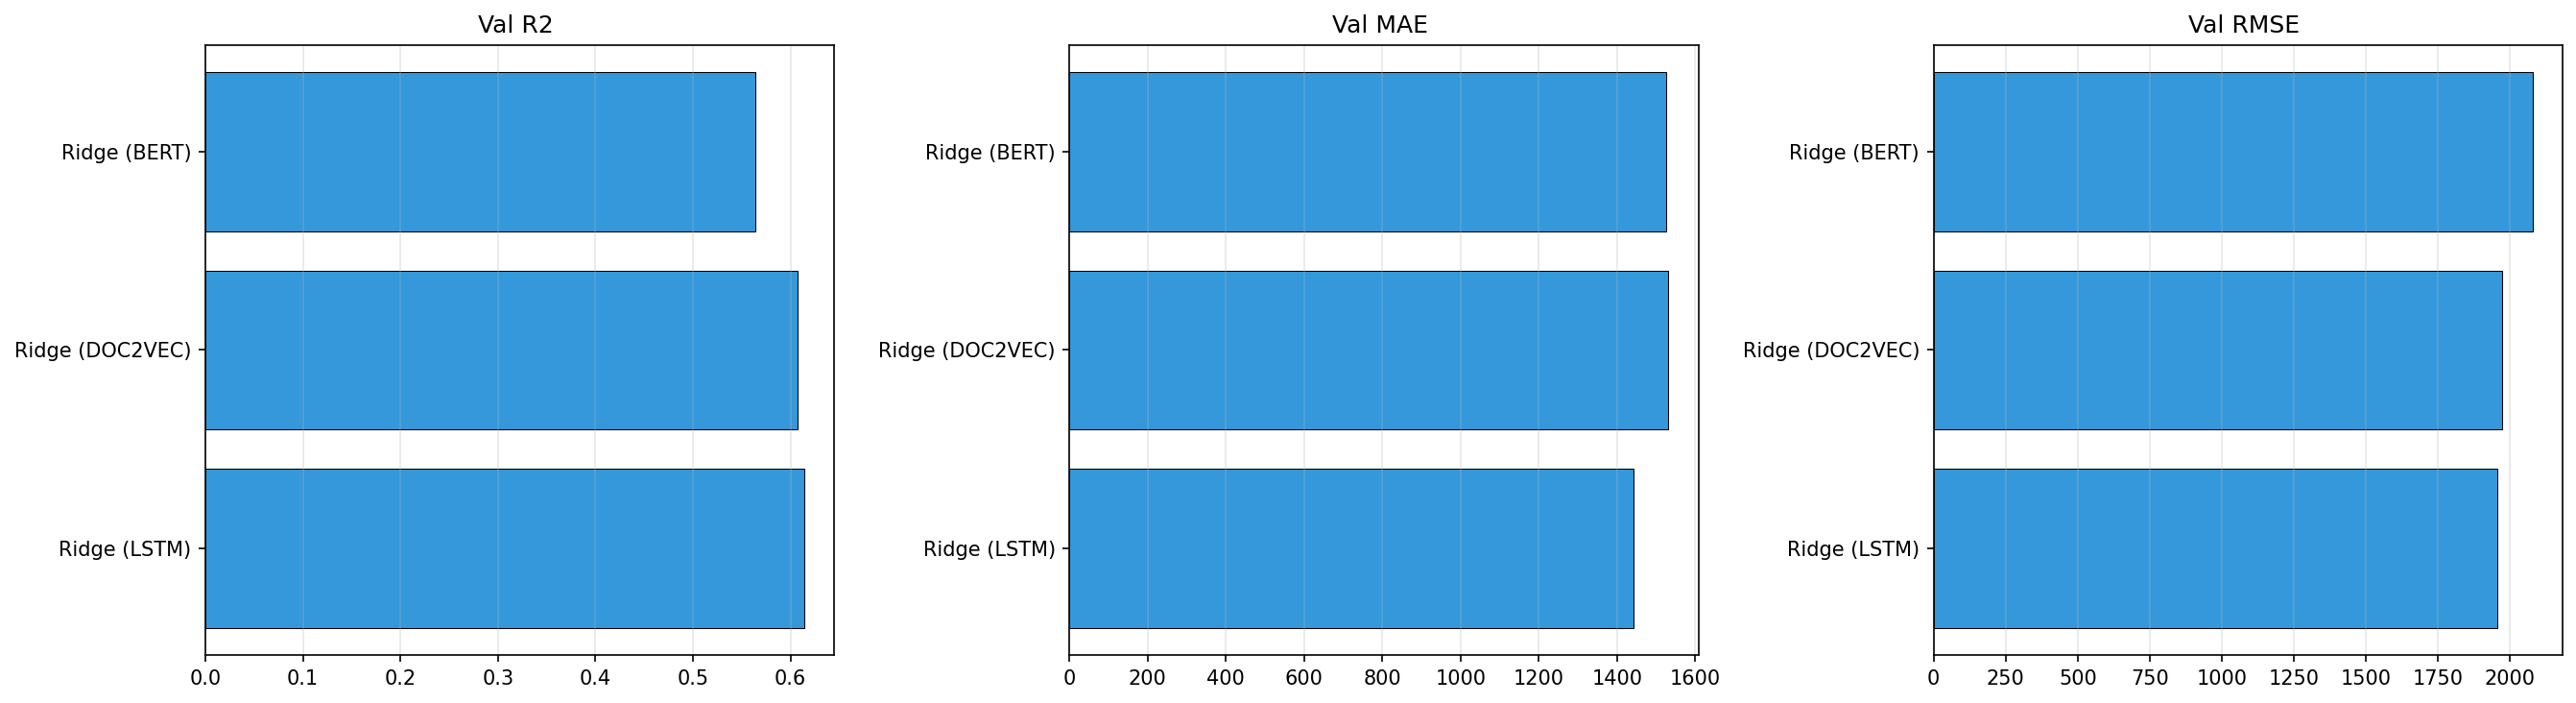

In [61]:
from IPython.display import Image, display
display(Image(filename='/kaggle/working/time_prediction_plots/0_model_comparison.png'))